### Parse synapses

Goal: count how many synapses are between each cell 

Notes:
- All GCs are sources and all MCs and TCs are dest's
- The json defines all the connections so if "is_reciprocal": true, it means there is a recirocal connection

In [1]:
import json
import yaml
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [2]:

slices_dir = os.path.join('/home/ellismith/OlfactoryBulb/olfactorybulb/slices')

#file_names = ['GCs__MCs', 'GCs__TCs']
file_names = ['GCs__TCs']

for file_name in file_names:

    # import file into a dictionary
    with open(f'{slices_dir}/DorsalColumnSlice/{file_name}.json','r') as f:
        cells = json.load(f)

    # create dictionary to initalize DataFrame with
    df_contents = {'Cell': ['MC1', 'MC2', 'MC3', 'MC4', 'MC5', 
                            'TC1', 'TC2', 'TC3', 'TC4', 'TC5', 
                            'GC1', 'GC2', 'GC3', 'GC4', 'GC5'],
                    'Source': [0, 0, 0, 0, 0,
                                0, 0, 0, 0, 0,
                                0, 0, 0, 0, 0],
                    'Destination': [0, 0, 0, 0, 0,
                                    0, 0, 0, 0, 0,
                                    0, 0, 0, 0, 0]}

    # initialize DataFrame
    syn_df = pd.DataFrame(df_contents)

    # set the index of DataFrame to Cell 
    syn_df = syn_df.set_index('Cell')

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        # get the source and destination cell types (first three characters, i.e. MC5, MC4, ...) 
        source_cell = entry['source_section'][:3]
        dest_cell = entry['dest_section'][:3]

        # get row of DataFrame that matches the source and destination cell types
        source_row = syn_df.loc[source_cell]  # syn_df[syn_df['Cell'] == source_cell]
        dest_row = syn_df.loc[dest_cell]  # syn_df[syn_df['Cell'] == dest_cell]

        # check that all synapses are reciprocal
        assert entry['is_reciprocal'] == True 
        
        # increment source and destination cell type counts
        syn_df.at[source_cell,'Source'] = source_row.Source + 1
        syn_df.at[dest_cell,'Destination'] = dest_row.Source + 1

    # write DataFrame to pickle (for reimporting as a DataFrame) and yaml (for viewing) files
    syn_df.to_pickle(f'{slices_dir}/{file_name}_synapse_counts.pkl', protocol=3)
    with open(f'{slices_dir}/{file_name}_synapse_counts.yaml', 'w') as outfile:
        yaml.dump(syn_df.to_dict(),outfile)



In [3]:
syn_df

,Source,Destination
Cell,,
MC1,0,0
MC2,0,0
MC3,0,0
MC4,0,0
MC5,0,0
TC1,0,0
TC2,0,0
TC3,0,1
TC4,0,1


In [4]:

slices_dir = os.path.join('/home/ellismith/OlfactoryBulb/olfactorybulb/slices')

file_names = ['GCs__MCs']

for file_name in file_names:

    # import file into a dictionary
    with open(f'{slices_dir}/DorsalColumnSlice/{file_name}.json','r') as f:
        cells = json.load(f)

    # create dictionary to initalize DataFrame with
    df_contents = {
        'Exc_Cell': ['MC1', 'MC2', 'MC3', 'MC4', 'MC5', 
                            'TC1', 'TC2', 'TC3', 'TC4', 'TC5'],
                    'GC1': [0, 0, 0, 0, 0,
                                0, 0, 0, 0, 0],
                    'GC2': [0, 0, 0, 0, 0,
                                    0, 0, 0, 0, 0],
                    'GC3': [0, 0, 0, 0, 0,
                                0, 0, 0, 0, 0],
                    'GC4': [0, 0, 0, 0, 0,
                                0, 0, 0, 0, 0],
                    'GC5': [0, 0, 0, 0, 0,
                                0, 0, 0, 0, 0]}

    # initialize DataFrame
    syn_df = pd.DataFrame(df_contents)

    # set the index of DataFrame to Cell 
    syn_df = syn_df.set_index('Exc_Cell')

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        # get the source and destination cell types (first three characters, i.e. MC5, MC4, ...) 
        source_cell = entry['source_section'][:3]
        dest_cell = entry['dest_section'][:3]

        # check that all synapses are reciprocal
        assert entry['is_reciprocal'] == True 
        
        # increment synapse counts - all GCs are sources and all MCs and TCs are dest's
        syn_df.loc[dest_cell][source_cell] = syn_df.loc[dest_cell][source_cell] + 1


    # write DataFrame to pickle (for reimporting as a DataFrame) and yaml (for viewing) files
    syn_df.to_pickle(f'{slices_dir}/{file_name}_synapse_counts.pkl', protocol=3)
    with open(f'{slices_dir}/{file_name}_synapse_counts.yaml', 'w') as outfile:
        yaml.dump(syn_df.to_dict(),outfile)



In [5]:

slices_dir = os.path.join('/home/ellismith/OlfactoryBulb/olfactorybulb/slices')

file_names = ['GCs__TCs']

for file_name in file_names:

    # import file into a dictionary
    with open(f'{slices_dir}/DorsalColumnSlice/{file_name}.json','r') as f:
        cells = json.load(f)

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        # get the source and destination cell types (first three characters, i.e. MC5, MC4, ...) 
        source_cell = entry['source_section'][:3]
        dest_cell = entry['dest_section'][:3]

        # check that all synapses are reciprocal
        assert entry['is_reciprocal'] == True 
        
        # increment synapse counts - all GCs are sources and all MCs and TCs are dest's
        syn_df.loc[dest_cell][source_cell] = syn_df.loc[dest_cell][source_cell] + 1


    # write DataFrame to pickle (for reimporting as a DataFrame) and yaml (for viewing) files
    syn_df.to_pickle(f'{slices_dir}/{file_name}_synapse_counts.pkl', protocol=3)
    with open(f'{slices_dir}/{file_name}_synapse_counts.yaml', 'w') as outfile:
        yaml.dump(syn_df.to_dict(),outfile)



In [6]:
syn_df

,GC1,GC2,GC3,GC4,GC5
Exc_Cell,,,,,
MC1,0,0,0,0,0
MC2,0,0,0,0,0
MC3,0,0,0,0,0
MC4,187,9,267,45,53
MC5,348,26,987,170,146
TC1,0,0,0,0,0
TC2,0,0,0,0,0
TC3,35,0,6,13,0
TC4,371,0,524,219,64


### Synapses between individual cells

In [7]:
def get_synapses(file_name):
    slices_dir = os.path.join('/home/ellismith/OlfactoryBulb/olfactorybulb/slices')

    #file_name = 'GCs__MCs'

    source_cells = []
    inh_cell_sections = []   
    source_cell_ids = []
    dest_cells = []    # i.e. TC4[2]
    exc_cell_sections = []     # i.e. "TC4[2].dend[7]"
    dest_cell_ids = []     # i.e. 2

    # import file into a dictionary
    with open(f'{slices_dir}/DorsalColumnSlice/{file_name}.json','r') as f:
        cells = json.load(f)

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        # get the source and destination cell types (first three characters, i.e. MC5, MC4, ...) 
        source_cell = entry['source_section'].split('.')[0]
        inh_cell_section = entry['source_section']
        source_cells.append(source_cell)
        inh_cell_sections.append(inh_cell_section)
        exc_cell_section = entry['dest_section']
        dest_cell = entry['dest_section'].split('.')[0]
        dest_cells.append(dest_cell)
        exc_cell_sections.append(exc_cell_section)

        # to get the cell number that's inside the brackets
        source_cell_id = int(source_cell[3:][1:-1])
        source_cell_ids.append(source_cell_id)
        dest_cell_id = int(dest_cell[3:][1:-1])
        dest_cell_ids.append(dest_cell_id)

        # check that all synapses are reciprocal
        assert entry['is_reciprocal'] == True 
        
    # ordering the GCs and MC/TCs in order of cell type number using only unique cell id's
    inh_cells = sorted(set(source_cells))
    exc_cells = sorted(set(dest_cells))

    # initialize DataFrame
    syn_df = pd.DataFrame(0, columns = inh_cells, index = exc_cells)

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        source_cell = entry['source_section'].split('.')[0]
        dest_cell = entry['dest_section'].split('.')[0]
        # increment synapse counts - all GCs are sources and all MCs and TCs are dest's
        syn_df.loc[dest_cell][source_cell] = syn_df.loc[dest_cell][source_cell] + 1

    syn_df.loc[:,'Row_Total'] = syn_df.sum(axis=1)
    syn_df.loc['Column_Total']= syn_df.sum(axis=0)

    # write DataFrame to pickle (for reimporting as a DataFrame) and yaml (for viewing) files
    #syn_df.to_pickle(f'{slices_dir}/{file_name}_synapse_counts.pkl', protocol=3)
    #with open(f'{slices_dir}/{file_name}_synapse_counts.yaml', 'w') as outfile:
    #    yaml.dump(syn_df.to_dict(),outfile)

    return syn_df, inh_cell_sections, exc_cell_sections, exc_cells, inh_cells


In [8]:
def get_cropped_df(syn_df):
    # to get rid of the sum row and column 
    syn_df.drop(syn_df.tail(1).index,inplace=True)
    syn_df.drop(columns=['Row_Total'], inplace=True)
    df = syn_df
    return df

In [9]:
def get_syn_maxmin_df(df):
    
    df.loc[:, 'Row_Max'] = df.max(axis=1)

    maxValueIndex = df.idxmax(axis=1)     # find the column name of max values in every row
    df['Max_idx'] = np.array(maxValueIndex)
    df.loc['Column_Max'] = df.max(axis=0)

    df.loc[:, 'Row_Min'] = df.min(axis=1)
    df.loc['Column_Min'] = df.min(axis=0)
    return df

In [10]:
def get_syn_avg_df(df):
    
    df.loc[:, 'Row_Avg'] = df.mean(axis=1)
    df.loc['Column_Avg'] = df.mean(axis=0)

    return df

In [11]:
def plot_synapse_heatmap(df):
    ##syn_df.sort_index(level=0, ascending=True, inplace=True)
    fig, ax = plt.subplots(figsize=(15, 5))
    sns.heatmap(df)

In [19]:
mc_syn_df, gc_sect_to_mc, mc_sect_to_gc, mcs_conn_to_gcs, gcs_conn_to_mcs = get_synapses('GCs__MCs')
#mc_syn_df1 =mc_syn_df.iloc[:,-11:]
mc_syn_df

,GC1[100],GC1[12],GC1[16],GC1[18],GC1[24],GC1[28],GC1[2],GC1[32],GC1[36],GC1[38],...,GC5[46],GC5[48],GC5[50],GC5[54],GC5[56],GC5[58],GC5[64],GC5[68],GC5[70],Row_Total
MC4[0],0,0,3,6,0,4,0,0,0,0,...,4,0,2,4,0,0,0,0,8,255
MC4[2],0,0,0,4,0,0,0,0,0,0,...,2,0,9,0,3,0,0,8,2,306
MC5[0],0,0,0,0,0,0,0,4,6,0,...,0,0,0,0,0,0,0,0,0,245
MC5[10],0,0,0,0,0,0,0,7,0,0,...,0,0,0,0,0,0,0,0,0,70
MC5[12],2,3,0,0,0,0,2,0,0,0,...,0,4,2,2,0,0,14,10,0,257
MC5[14],1,0,0,0,0,4,1,0,0,0,...,0,4,0,6,0,0,2,8,0,193
MC5[2],0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,109
MC5[4],0,0,8,0,0,2,4,15,2,0,...,0,0,0,0,0,0,0,0,0,281
MC5[6],0,0,0,10,0,4,10,0,0,0,...,0,8,4,4,0,2,2,6,0,224
MC5[8],0,0,16,0,0,0,2,9,0,4,...,0,0,0,0,6,0,0,0,0,298


In [20]:
mc_df = get_cropped_df(mc_syn_df)
mc_df

,GC1[100],GC1[12],GC1[16],GC1[18],GC1[24],GC1[28],GC1[2],GC1[32],GC1[36],GC1[38],...,GC5[42],GC5[46],GC5[48],GC5[50],GC5[54],GC5[56],GC5[58],GC5[64],GC5[68],GC5[70]
MC4[0],0,0,3,6,0,4,0,0,0,0,...,7,4,0,2,4,0,0,0,0,8
MC4[2],0,0,0,4,0,0,0,0,0,0,...,0,2,0,9,0,3,0,0,8,2
MC5[0],0,0,0,0,0,0,0,4,6,0,...,0,0,0,0,0,0,0,0,0,0
MC5[10],0,0,0,0,0,0,0,7,0,0,...,0,0,0,0,0,0,0,0,0,0
MC5[12],2,3,0,0,0,0,2,0,0,0,...,0,0,4,2,2,0,0,14,10,0
MC5[14],1,0,0,0,0,4,1,0,0,0,...,0,0,4,0,6,0,0,2,8,0
MC5[2],0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MC5[4],0,0,8,0,0,2,4,15,2,0,...,0,0,0,0,0,0,0,0,0,0
MC5[6],0,0,0,10,0,4,10,0,0,0,...,1,0,8,4,4,0,2,2,6,0
MC5[8],0,0,16,0,0,0,2,9,0,4,...,0,0,0,0,0,6,0,0,0,0


In [14]:
mc_syn_df_ = get_syn_maxmin_df(mc_syn_df)
mc_syn_df_

,GC1[100],GC1[12],GC1[16],GC1[18],GC1[24],GC1[28],GC1[2],GC1[32],GC1[36],GC1[38],...,GC5[50],GC5[54],GC5[56],GC5[58],GC5[64],GC5[68],GC5[70],Row_Max,Max_idx,Row_Min
MC4[0],0,0,3,6,0,4,0,0,0,0,...,2,4,0,0,0,0,8,17,GC3[276],0
MC4[2],0,0,0,4,0,0,0,0,0,0,...,9,0,3,0,0,8,2,29,GC1[96],0
MC5[0],0,0,0,0,0,0,0,4,6,0,...,0,0,0,0,0,0,0,26,GC3[114],0
MC5[10],0,0,0,0,0,0,0,7,0,0,...,0,0,0,0,0,0,0,12,GC3[116],0
MC5[12],2,3,0,0,0,0,2,0,0,0,...,2,2,0,0,14,10,0,33,GC4[0],0
MC5[14],1,0,0,0,0,4,1,0,0,0,...,0,6,0,0,2,8,0,12,GC5[26],0
MC5[2],0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,15,GC3[302],0
MC5[4],0,0,8,0,0,2,4,15,2,0,...,0,0,0,0,0,0,0,22,GC3[114],0
MC5[6],0,0,0,10,0,4,10,0,0,0,...,4,4,0,2,2,6,0,15,GC1[86],0
MC5[8],0,0,16,0,0,0,2,9,0,4,...,0,0,6,0,0,0,0,18,GC1[56],0


In [21]:
mc_syn_df_avg = get_syn_avg_df(mc_df)
mc_syn_df_avg

,GC1[100],GC1[12],GC1[16],GC1[18],GC1[24],GC1[28],GC1[2],GC1[32],GC1[36],GC1[38],...,GC5[46],GC5[48],GC5[50],GC5[54],GC5[56],GC5[58],GC5[64],GC5[68],GC5[70],Row_Avg
MC4[0],0.0,0.0,3.0,6.0,0.0,4.0,0.0,0.0,0.0,0.0,...,4.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,8.0,1.645161
MC4[2],0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,9.0,0.0,3.0,0.0,0.0,8.0,2.0,1.974194
MC5[0],0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.580645
MC5[10],0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.451613
MC5[12],2.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,4.0,2.0,2.0,0.0,0.0,14.0,10.0,0.0,1.658065
MC5[14],1.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,...,0.0,4.0,0.0,6.0,0.0,0.0,2.0,8.0,0.0,1.245161
MC5[2],0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.703226
MC5[4],0.0,0.0,8.0,0.0,0.0,2.0,4.0,15.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.812903
MC5[6],0.0,0.0,0.0,10.0,0.0,4.0,10.0,0.0,0.0,0.0,...,0.0,8.0,4.0,4.0,0.0,2.0,2.0,6.0,0.0,1.445161
MC5[8],0.0,0.0,16.0,0.0,0.0,0.0,2.0,9.0,0.0,4.0,...,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,1.922581


In [22]:
print('MC with the most synapses with GCs, on average: ', mc_syn_df_avg['Row_Avg'].idxmax(), mc_syn_df_avg['Row_Avg'].max())
print('GC with the most synapses with MCs, on average: ', mc_syn_df_avg.idxmax(axis=1)['Column_Avg'], mc_syn_df_avg.max(axis=1)['Column_Avg'])

MC with the most synapses with GCs, on average:  MC4[2] 1.9741935483870967
GC with the most synapses with MCs, on average:  GC3[266] 6.6


In [12]:
tc_syn_df, gc_sect_to_tc, tc_sect_to_gc, tcs_conn_to_gcs, gcs_conn_to_tcs = get_synapses('GCs__TCs')
#tc_syn_df1 =tc_syn_df.iloc[:,-11:] # show subset of GCs
tc_syn_df

,GC1[16],GC1[18],GC1[28],GC1[2],GC1[32],GC1[54],GC1[56],GC1[58],GC1[64],GC1[72],...,GC4[32],GC4[34],GC4[44],GC5[20],GC5[24],GC5[30],GC5[56],GC5[60],GC5[64],Row_Total
TC3[0],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,13
TC3[2],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,22
TC3[4],0,0,0,0,0,8,0,0,0,0,...,0,4,0,0,0,0,0,0,0,19
TC4[0],0,0,0,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,123
TC4[10],2,3,0,0,0,0,0,0,0,20,...,0,0,12,0,16,0,0,0,0,159
TC4[12],0,22,0,0,0,0,0,0,0,0,...,0,6,24,0,0,0,0,0,0,105
TC4[14],0,0,0,0,0,0,0,0,0,0,...,0,14,25,0,0,0,0,0,0,86
TC4[16],0,9,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,0,0,125
TC4[2],66,0,0,0,0,0,24,7,0,0,...,0,0,22,0,16,0,18,0,0,272
TC4[4],0,0,0,0,0,3,0,0,0,0,...,0,0,4,0,0,0,0,0,0,11


In [13]:
tc_df = get_cropped_df(tc_syn_df)
tc_df

,GC1[16],GC1[18],GC1[28],GC1[2],GC1[32],GC1[54],GC1[56],GC1[58],GC1[64],GC1[72],...,GC4[30],GC4[32],GC4[34],GC4[44],GC5[20],GC5[24],GC5[30],GC5[56],GC5[60],GC5[64]
TC3[0],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TC3[2],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TC3[4],0,0,0,0,0,8,0,0,0,0,...,0,0,4,0,0,0,0,0,0,0
TC4[0],0,0,0,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TC4[10],2,3,0,0,0,0,0,0,0,20,...,0,0,0,12,0,16,0,0,0,0
TC4[12],0,22,0,0,0,0,0,0,0,0,...,0,0,6,24,0,0,0,0,0,0
TC4[14],0,0,0,0,0,0,0,0,0,0,...,0,0,14,25,0,0,0,0,0,0
TC4[16],0,9,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,0,0,0
TC4[2],66,0,0,0,0,0,24,7,0,0,...,0,0,0,22,0,16,0,18,0,0
TC4[4],0,0,0,0,0,3,0,0,0,0,...,0,0,0,4,0,0,0,0,0,0


In [14]:
tc_syn_df_ = get_syn_maxmin_df(tc_df)
tc_syn_df_

,GC1[16],GC1[18],GC1[28],GC1[2],GC1[32],GC1[54],GC1[56],GC1[58],GC1[64],GC1[72],...,GC4[44],GC5[20],GC5[24],GC5[30],GC5[56],GC5[60],GC5[64],Row_Max,Max_idx,Row_Min
TC3[0],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,9,GC1[8],0
TC3[2],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,13,GC1[74],0
TC3[4],0,0,0,0,0,8,0,0,0,0,...,0,0,0,0,0,0,0,8,GC1[54],0
TC4[0],0,0,0,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,41,GC3[0],0
TC4[10],2,3,0,0,0,0,0,0,0,20,...,12,0,16,0,0,0,0,25,GC1[94],0
TC4[12],0,22,0,0,0,0,0,0,0,0,...,24,0,0,0,0,0,0,24,GC4[44],0
TC4[14],0,0,0,0,0,0,0,0,0,0,...,25,0,0,0,0,0,0,25,GC4[44],0
TC4[16],0,9,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,91,GC3[208],0
TC4[2],66,0,0,0,0,0,24,7,0,0,...,22,0,16,0,18,0,0,66,GC1[16],0
TC4[4],0,0,0,0,0,3,0,0,0,0,...,4,0,0,0,0,0,0,4,GC3[90],0


In [14]:
tc_syn_df_avg = get_syn_avg_df(tc_df)
tc_syn_df_avg

,GC1[16],GC1[18],GC1[28],GC1[2],GC1[32],GC1[54],GC1[56],GC1[58],GC1[64],GC1[72],...,GC4[32],GC4[34],GC4[44],GC5[20],GC5[24],GC5[30],GC5[56],GC5[60],GC5[64],Row_Avg
TC3[0],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.250000
TC3[2],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.423077
TC3[4],0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.365385
TC4[0],0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,2.365385
TC4[10],2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,0.000000,0.000000,12.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.0,3.057692
TC4[12],0.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,6.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,2.019231
TC4[14],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,14.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.653846
TC4[16],0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,2.403846
TC4[2],66.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,7.000000,0.000000,0.000000,...,0.000000,0.000000,22.000000,0.000000,16.000000,0.000000,18.000000,0.000000,0.0,5.230769
TC4[4],0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.211538


In [23]:
print('TC with the most synapses with GCs, on average: ', tc_syn_df_avg['Row_Avg'].idxmax(), tc_syn_df_avg['Row_Avg'].max())
print('GC with the most synapses with TCs, on average: ', tc_syn_df_avg.idxmax(axis=1)['Column_Avg'], tc_syn_df_avg.max(axis=1)['Column_Avg'])

TC with the most synapses with GCs, on average:  TC4[2] 5.230769230769231
GC with the most synapses with TCs, on average:  GC3[0] 6.6521739130434785


In [15]:
gcs_to_mcs = set(gcs_conn_to_mcs)
gcs_to_tcs = set(gcs_conn_to_tcs)
gcs_total = gcs_to_mcs.union(gcs_to_tcs)

In [16]:
def get_cell_info(file_name):
    slices_dir = os.path.join('/home/ellismith/OlfactoryBulb/olfactorybulb/slices')

    radii = []
    children = []
    names = []

    # import file into a dictionary
    with open(f'{slices_dir}/DorsalColumnSlice/{file_name}.json','r') as f:
        cells = json.load(f)

    for root in cells['roots']:
        radii_cell = root['radii']
        radii.append(radii_cell)
        children_cell = root['children']
        children.append(children_cell)
        name = root['name'].split('.')[0]
        names.append(name)
    
    return radii, children, names

In [17]:
cell_types = ['MCs', 'TCs', 'GCs']

mc_radii, mc_children, mc_names = get_cell_info('MCs')
tc_radii, tc_children, tc_names = get_cell_info('TCs')
gc_radii, gc_children, gc_names = get_cell_info('GCs')

# initialize cell info DataFrame
cols = 'num_cells', 'cells_syn_w_MCs', 'cells_syn_w_TCs', 'cells_syn_w_GCs', 'total_syn_w_MCs', 'total_syn_w_TCs', 'total_syn_w_GCs'
cell_df = pd.DataFrame(0, columns = cols, index = cell_types)

In [18]:
cell_df.loc['MCs']['num_cells'] = len(mc_radii)
cell_df.loc['TCs']['num_cells'] = len(tc_radii)
cell_df.loc['GCs']['num_cells'] = len(gc_radii)
assert(len(gc_radii)==len(gcs_total))  # check that the gcs that form synapses are the same gcs from GCs.json

cell_df.loc['MCs']['cells_syn_w_GCs'] = len(mcs_conn_to_gcs)
cell_df.loc['GCs']['cells_syn_w_MCs'] = len(gcs_conn_to_mcs)
cell_df.loc['TCs']['cells_syn_w_GCs'] = len(tcs_conn_to_gcs)
cell_df.loc['GCs']['cells_syn_w_TCs'] = len(gcs_conn_to_tcs)

cell_df.loc['MCs']['total_syn_w_GCs'] = len(mc_to_gc_syns)
cell_df.loc['GCs']['total_syn_w_MCs'] = len(gc_to_mc_syns)
cell_df.loc['TCs']['total_syn_w_GCs'] = len(tc_to_gc_syns)
cell_df.loc['GCs']['total_syn_w_TCs'] = len(gc_to_tc_syns)

cell_df

,num_cells,cells_syn_w_MCs,cells_syn_w_TCs,cells_syn_w_GCs,total_syn_w_MCs,total_syn_w_TCs,total_syn_w_GCs
MCs,10,0,0,10,0,0,2238
TCs,24,0,0,23,0,0,1751
GCs,159,155,52,0,2238,1751,0


In [20]:
xs = []
ys = []
zs = []
for i in range(len(gc_radii)):
    xs.append(gc_radii[i][0])
    ys.append(gc_radii[i][1])
    zs.append(gc_radii[i][2])

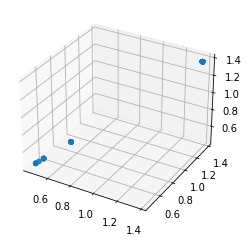

In [21]:
ax = plt.axes(projection='3d')
ax.scatter(xs, ys, zs)

In [22]:
mc_xs

NameError: name 'mc_xs' is not defined